### Dependencies

In [1]:
%pip install networkx

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [50]:
import networkx as nx
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [43]:
import warnings
warnings.filterwarnings('default')

### Exercise 1

In [46]:
def ex1_1(num_maximum_edges=None):
    astro_ph_file = open('ca-AstroPh.txt', 'r')

    edge_weights = dict()
    for idx, line in enumerate(astro_ph_file):
        node_0, node_1 = line.strip().split()
        node_0 = int(node_0)
        node_1 = int(node_1)

        if node_0 > node_1:
            aux = node_0
            node_0 = node_1
            node_1 = aux

        edge = (node_0, node_1)
        if edge not in edge_weights:
            edge_weights[edge] = 0
        edge_weights[edge] += 1

        if num_maximum_edges is not None:
            if idx == num_maximum_edges - 1:
                break

    astro_ph_file.close()

    G = nx.Graph()
    for edge, weight in edge_weights.items():
        node_0, node_1 = edge
        G.add_edge(node_0, node_1, weight=weight)

    print(f'Number of Nodes: {G.number_of_nodes()}')
    print(f'Number of Edges: {G.number_of_edges()}')

    return G


graph_ex1_1 = ex1_1(num_maximum_edges=None)

Number of Nodes: 18772
Number of Edges: 198110


In [47]:
def ex1_2(graph):
    
    for node in graph.nodes():
        neighbors = list(graph.neighbors(node))
        egonet = graph.subgraph(neighbors)

        egonet_num_neighbors = len(neighbors)
        egonet_num_edges = egonet.number_of_edges()
        egonet_total_weight = sum([data['weight'] for _, _, data in egonet.edges(data=True)])

        if egonet_num_neighbors == 0:
            principal_eigen_value = 0.0
        else:
            adjacency_matrix = nx.adjacency_matrix(egonet, weight='weight').todense()
            eigen_values = np.linalg.eigvals(adjacency_matrix)
            principal_eigen_value = eigen_values[np.argmax(np.real(eigen_values))].real

        graph.nodes[node]['egonet_num_neighbors'] = egonet_num_neighbors
        graph.nodes[node]['egonet_num_edges'] = egonet_num_edges
        graph.nodes[node]['egonet_total_weight'] = egonet_total_weight
        graph.nodes[node]['egonet_principal_eigen_value'] = principal_eigen_value

    return graph


graph_ex1_2 = ex1_2(graph_ex1_1)

In [48]:
def ex1_3(graph):

    nodes = np.array(list(graph.nodes()))
    egonet_num_neighbors = np.array([graph.nodes[node]['egonet_num_neighbors'] for node in graph.nodes()])
    egonet_num_edges = np.array([graph.nodes[node]['egonet_num_edges'] for node in graph.nodes()])

    filter_mask = ((0 < egonet_num_neighbors) & (0 < egonet_num_edges))
    nodes = nodes[filter_mask]
    egonet_num_neighbors = egonet_num_neighbors[filter_mask]
    egonet_num_edges = egonet_num_edges[filter_mask]

    X = np.log(egonet_num_neighbors).reshape(-1, 1)
    Y = np.log(egonet_num_edges).reshape(-1, 1)

    linear_regression = LinearRegression()
    linear_regression.fit(X, Y)

    C = np.exp(linear_regression.intercept_[0])
    theta = linear_regression.coef_[0][0]

    print(f'Linear Regression: C={C} theta={theta}')

    egonet_num_edges_pred = C * (egonet_num_neighbors ** theta)

    for idx, node in enumerate(nodes):
        numerator = max(egonet_num_edges[idx], egonet_num_edges_pred[idx])
        denominator = min(egonet_num_edges[idx], egonet_num_edges_pred[idx])
        logarithm = np.log(np.abs(egonet_num_edges[idx] - egonet_num_edges_pred[idx]) + 1.0)

        anomaly_score = (numerator / denominator) * logarithm
        graph.nodes[node]['anomaly_score'] = anomaly_score

    for node in graph.nodes():
        if node not in nodes:
            graph.nodes[node]['anomaly_score'] = 0.0

    return graph


graph_ex1_3 = ex1_3(graph_ex1_2)

Linear Regression: C=0.3635384228253787 theta=1.8352598950628716


Number of Nodes: 1103
Number of Edges: 1458
Linear Regression: C=0.5641203797554226 theta=0.8565427600164709
Top 10 Anomaly Scores:
Node: 101811 Anomaly Score: 22.345022141798275
Node: 60471 Anomaly Score: 12.10955964592779
Node: 106274 Anomaly Score: 9.66557521541992
Node: 76529 Anomaly Score: 9.517514111173108
Node: 126916 Anomaly Score: 8.540231669352812
Node: 127393 Anomaly Score: 7.341137939950143
Node: 84424 Anomaly Score: 6.814219809695031
Node: 35111 Anomaly Score: 6.793791754337157
Node: 40339 Anomaly Score: 6.516960345673238
Node: 17097 Anomaly Score: 5.743182025184376


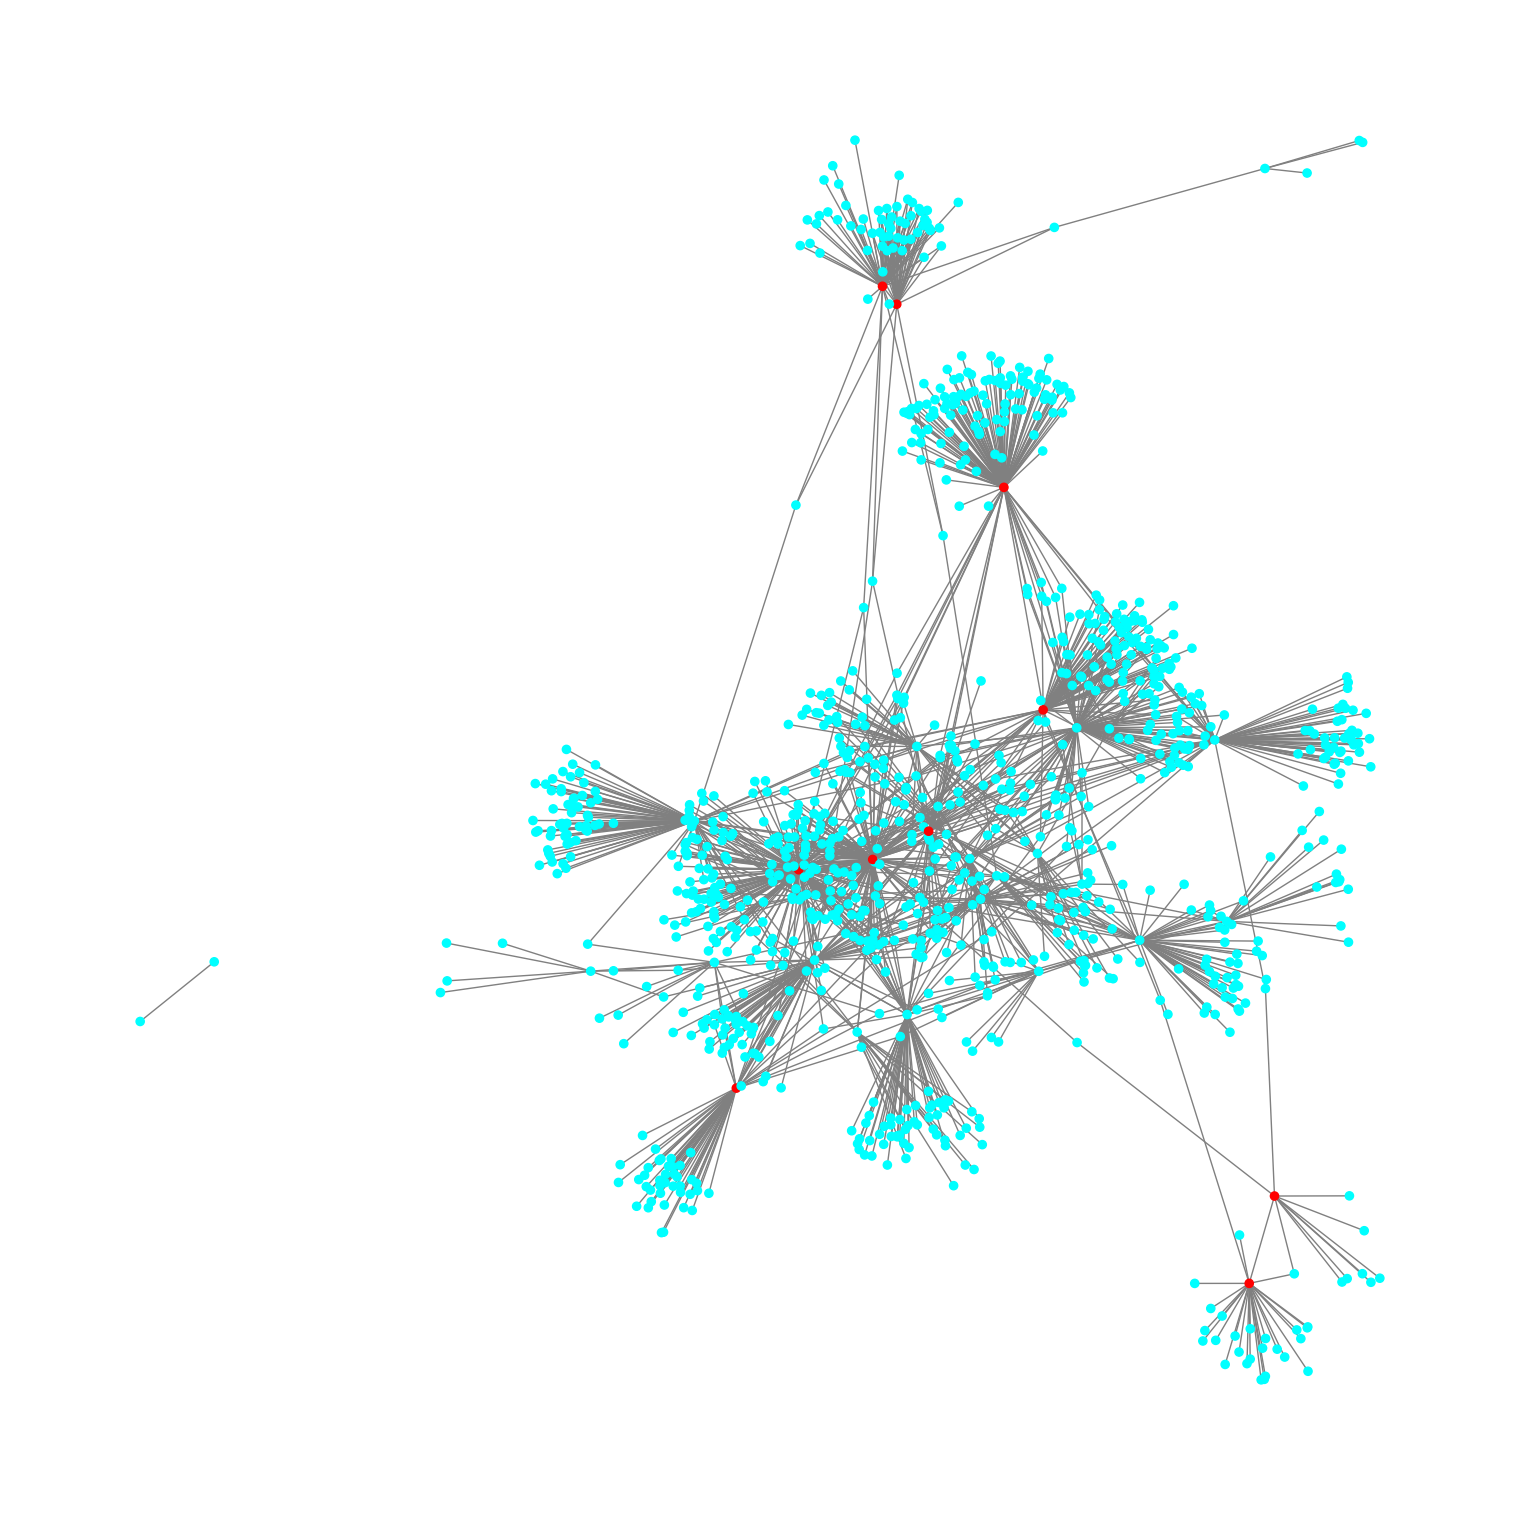

In [59]:
def ex1_4():
    graph = ex1_1(num_maximum_edges=1500)
    graph = ex1_2(graph)
    graph = ex1_3(graph)

    anomaly_scores = [(node, graph.nodes[node]['anomaly_score']) for node in graph.nodes()]
    sorted_anomaly_scores = sorted(anomaly_scores, key=lambda x: x[1], reverse=True)

    TOP = 10
    print(f'Top {TOP} Anomaly Scores:')
    for node, anomaly_score in sorted_anomaly_scores[:TOP]:
        print(f'Node: {node} Anomaly Score: {anomaly_score}')

    anomaly_nodes = set(node for node, _ in sorted_anomaly_scores[:TOP])

    plt.figure(figsize=(15, 15))
    positions = nx.spring_layout(graph, seed=23)

    node_colors = ['cyan' if node not in anomaly_nodes else 'red' for node in graph.nodes()]

    nx.draw(graph, pos=positions, node_color=node_colors, edge_color='gray', node_size=35)


ex1_4()